# Baseline e Modelação

> Objetivo: construir e avaliar três modelos baseline em ordem: Regressão Logística, Árvore de Decisão e Random Forest.

## Estrutura desta secção
1. Preparação dos dados
2. Baseline: Regressão Logística
3. Baseline: Árvore de Decisão
4. Baseline: Random Forest

In [36]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 1) Preparação dos dados

Nesta fase convertemos Grupo_pre e Sexo para categóricas, definimos X_raw e y, fazemos o split estratificado e aplicamos one-hot encoding para todos os modelos baseline.

In [37]:
# Converter variáveis categóricas e definir X/y
ortho_clean["Grupo_pre"] = ortho_clean["Grupo_pre"].astype("category")
ortho_clean["Sexo"] = ortho_clean["Sexo"].astype("category")

X = ortho_clean.drop("mudanca_CPAK", axis=1)
y = ortho_clean["mudanca_CPAK"]

In [38]:
# Verificação de valores nulos em X
X.isnull().sum()

Idade        0
Sexo         0
Peso         0
Altura_cm    0
IMC          0
Grupo_pre    0
Fle_0        0
EVA_0        0
PM6_0        0
WD_0         0
WR_0         0
WAtotal_0    0
WT_0         0
dtype: int64

In [39]:
# Verificação de valores nulos em y
y.isnull().sum()

np.int64(0)

In [40]:
# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [41]:
# Verificação da distribuição da target no conjunto de treino
print("Distribuição da Target (CPAK) - Treino")
print("N. observações Treino", len(X_train))
print(y_train.value_counts(normalize=True))

Distribuição da Target (CPAK) - Treino
N. observações Treino 183
mudanca_CPAK
0    0.901639
1    0.098361
Name: proportion, dtype: float64


In [21]:
# Verificação da distribuição da target no conjunto de teste

print("Distribuição da Target (CPAK) - Teste")
print("N. observações Teste", len(X_test))
print(y_test.value_counts(normalize=True))

Distribuição da Target (CPAK) - Teste
N. observações Teste 79
mudanca_CPAK
0    0.898734
1    0.101266
Name: proportion, dtype: float64


## 2) Baseline: Regressão Logística

Treino do modelo baseline de regressão logística e avaliação com métricas de classificação.

In [ ]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test)
y_pred_LR_prob = clf_LR.predict_proba(X_test)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.53764070e-01 4.62359301e-02]
 [9.82942248e-01 1.70577522e-02]
 [9.98100453e-01 1.89954670e-03]
 [7.01694235e-01 2.98305765e-01]
 [9.44362862e-01 5.56371381e-02]
 [8.97165592e-01 1.02834408e-01]
 [5.23774891e-01 4.76225109e-01]
 [9.24497042e-01 7.55029585e-02]
 [2.85022807e-02 9.71497719e-01]
 [6.00052652e-01 3.99947348e-01]
 [9.90291051e-01 9.70894895e-03]
 [6.74300019e-01 3.25699981e-01]
 [9.76403149e-01 2.35968511e-02]
 [9.95787922e-01 4.21207834e-03]
 [9.81453012e-01 1.85469877e-02]
 [9.46754785e-01 5.32452146e-02]
 [5.22128240e-01 4.77871760e-01]
 [9.29505626e-01 7.04943737e-02]
 [9.99797912e-01 2.02088035e-04]
 [9.76737873e-01 2.32621272e-02]
 [8.58803648e-01 1.41196352e-01]
 [9.98901823e-01 1.09817718e-03]
 [2.65381271e-01 7.34618729e-01]
 [8.89370475e-01 1.10629525e-01]
 [6.31276029e-01 3.68723971e-01]
 [9.70452874e-01 2.95471255e-02]
 [8.59937766e-01 1.40062234e-01]
 [9.18511964e-01 8.14880363e-02]
 [8.95376056e-01 1.04623944e-01]
 [3.09380744e-02 9.69061926e-01]
 [4.826567

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


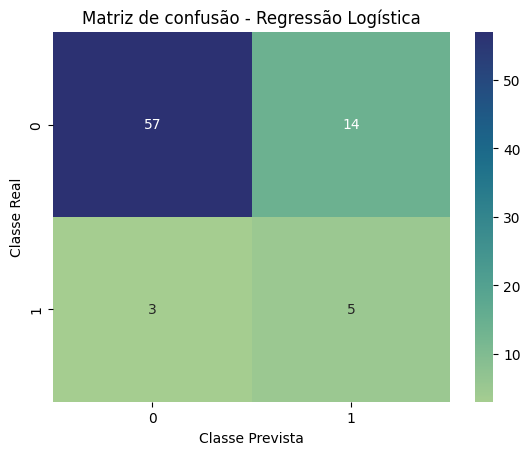

In [67]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)


# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Regressão Logística")
plt.show()

In [45]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        71
           1       0.38      0.38      0.38         8

    accuracy                           0.87        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.87      0.87      0.87        79



In [46]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print("AUC:", auc)

AUC: 0.6522887323943661


In [47]:
# Validação cruzada (K-fold) para estimar generalização
pred_cross_LR = cross_val_predict(clf_LR, X, y)

print(classification_report(y, pred_cross_LR, digits=4))


              precision    recall  f1-score   support

           0     0.9084    0.9661    0.9363       236
           1     0.2727    0.1154    0.1622        26

    accuracy                         0.8817       262
   macro avg     0.5905    0.5407    0.5493       262
weighted avg     0.8453    0.8817    0.8595       262



c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

In [70]:
# validação( stratified k-fold)

pred_cross_LR_strat = cross_val_predict(clf_LR, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5))

print(classification_report(y, pred_cross_LR_strat, digits=4))

              precision    recall  f1-score   support

           0     0.9415    0.7500    0.8349       236
           1     0.2027    0.5769    0.3000        26

    accuracy                         0.7328       262
   macro avg     0.5721    0.6635    0.5675       262
weighted avg     0.8682    0.7328    0.7818       262



c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

In [48]:
coeficientes_lr = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": clf_LR.coef_[0]
})

coeficientes_lr["Abs_Coeficiente"] = coeficientes_lr["Coeficiente"].abs()
coeficientes_lr.sort_values(by="Abs_Coeficiente", ascending=False)

,Variavel,Coeficiente,Abs_Coeficiente
4,IMC,-0.164713,0.164713
10,WR_0,0.095036,0.095036
0,Idade,-0.090328,0.090328
9,WD_0,-0.063032,0.063032
6,Fle_0,0.056236,0.056236
2,Peso,-0.047260,0.047260
7,EVA_0,0.037898,0.037898
12,WT_0,0.033584,0.033584
1,Sexo,-0.018654,0.018654
5,Grupo_pre,0.013031,0.013031


## 3) Baseline: Árvore de Decisão

Treino do modelo baseline de árvore de decisão e avaliação com métricas de classificação.

In [51]:
# Treino do baseline com Árvore de Decisão
clf_DT = tree.DecisionTreeClassifier(random_state=42)
clf_DT = clf_DT.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_DT = clf_DT.predict(X_test)
y_pred_DT

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

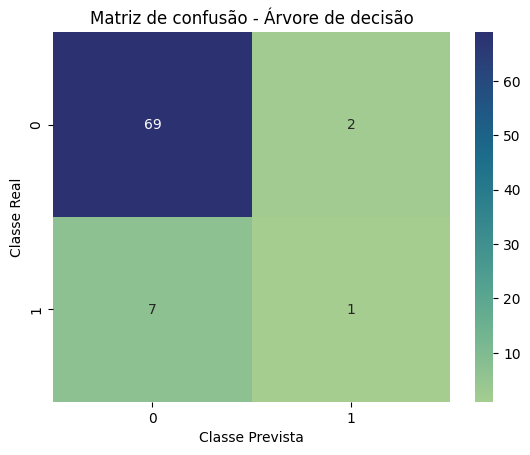

In [53]:
# Matriz de confusão do baseline (Árvore de Decisão)
confusion_m = confusion_matrix(y_test, y_pred_DT)

# Visualização da matriz de confusão
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Árvore de decisão")
plt.show()

In [54]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        71
           1       0.33      0.12      0.18         8

    accuracy                           0.89        79
   macro avg       0.62      0.55      0.56        79
weighted avg       0.85      0.89      0.86        79



In [55]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC:", auc)

AUC: 0.5484154929577465


In [57]:
# Validação cruzada (K-fold) para estimar generalização
pred = cross_val_predict(clf_DT, X, y)

print(classification_report(y, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9227    0.9110    0.9168       236
           1     0.2759    0.3077    0.2909        26

    accuracy                         0.8511       262
   macro avg     0.5993    0.6094    0.6039       262
weighted avg     0.8586    0.8511    0.8547       262



## 4) Baseline: Random Forest

Treino do modelo baseline de floresta aleatória e avaliação com métricas de classificação.

In [60]:
# Treino do baseline com Random Forest
clf_RF = RandomForestClassifier(random_state=42)
clf_RF = clf_RF.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_RF = clf_RF.predict(X_test)
print(y_pred_RF)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


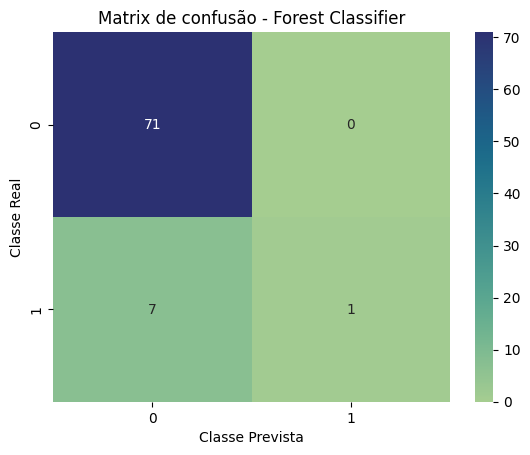

In [61]:
# matriz de confusão
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)

#gráfico de matriz de confusão
sns.heatmap(confusion_matrix_RF, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matrix de confusão - Forest Classifier")
plt.show()

In [62]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        71
           1       1.00      0.12      0.22         8

    accuracy                           0.91        79
   macro avg       0.96      0.56      0.59        79
weighted avg       0.92      0.91      0.88        79



In [64]:
#Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_pred_RF)
print("AUC:", auc)

AUC: 0.5625


In [65]:
# Cross Validation: K-fold
pred_cross_RF = cross_val_predict(clf_RF, X, y)

print(classification_report(y, pred_cross_RF, digits=4))



              precision    recall  f1-score   support

           0     0.9105    0.9915    0.9493       236
           1     0.6000    0.1154    0.1935        26

    accuracy                         0.9046       262
   macro avg     0.7553    0.5535    0.5714       262
weighted avg     0.8797    0.9046    0.8743       262

